# 01. 벡터와 행렬 연산 시각화

**목표:** 벡터 연산을 기하학적으로 이해하고, 로보틱스에서 어떻게 쓰이는지 연결한다.

**로보틱스 연결:**
- 벡터 = 로봇의 위치, 속도, 힘 방향
- 내적 = 두 관절 축이 얼마나 정렬되어 있는지
- 외적 = 회전축 방향 계산 (로봇 관절 제어)

$$\vec{a} \cdot \vec{b} = |\vec{a}||\vec{b}|\cos\theta$$

$$\vec{a} \times \vec{b} = |\vec{a}||\vec{b}|\sin\theta \cdot \hat{n}$$

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import os

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f8f8'
plt.rcParams['font.family'] = 'DejaVu Sans'

## 1. 벡터 덧셈 — 평행사변형 법칙

/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/1518123895.py:62: UserWarning: Glyph 48289 (\N{HANGUL SYLLABLE BEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/1518123895.py:62: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/1518123895.py:62: UserWarning: Glyph 45927 (\N{HANGUL SYLLABLE DEOS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/1518123895.py:62: UserWarning: Glyph 49480 (\N{HANGUL SYLLABLE SEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/1518123895.py:62: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykern

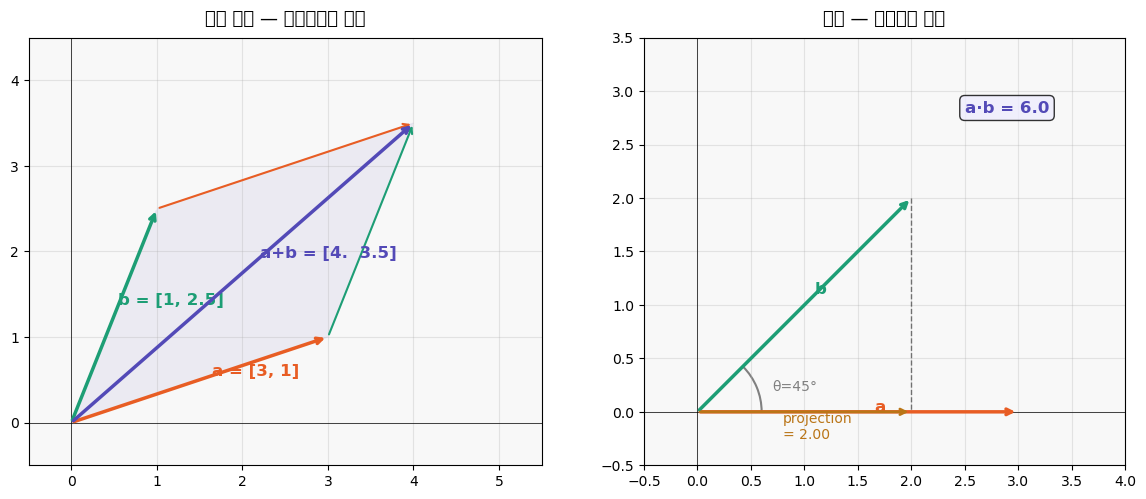

내적 a·b = 6.0
|a||b|cosθ = 6.0000


In [5]:
def plot_vector(ax, origin, vec, color, label, lw=2.5):
    ax.annotate('', xy=origin+vec, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    mid = origin + vec * 0.55
    ax.text(mid[0], mid[1], label, color=color, fontsize=12, fontweight='bold')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- 벡터 덧셈 ---
ax = axes[0]
a = np.array([3.0, 1.0])
b = np.array([1.0, 2.5])
origin = np.zeros(2)

plot_vector(ax, origin, a, '#E85D24', 'a = [3, 1]')
plot_vector(ax, origin, b, '#1D9E75', 'b = [1, 2.5]')
plot_vector(ax, a, b, '#1D9E75', '', lw=1.5)   # b를 a 끝에서
plot_vector(ax, b, a, '#E85D24', '', lw=1.5)   # a를 b 끝에서
plot_vector(ax, origin, a+b, '#534AB7', f'a+b = {a+b}')

# 평행사변형 점선
para = plt.Polygon([origin, a, a+b, b], fill=True,
                   facecolor='#534AB7', alpha=0.08, linestyle='--',
                   edgecolor='#534AB7', linewidth=1)
ax.add_patch(para)
ax.set_xlim(-0.5, 5.5); ax.set_ylim(-0.5, 4.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title('벡터 덧셈 — 평행사변형 법칙', fontsize=13, pad=10)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)

# --- 내적 시각화 ---
ax2 = axes[1]
a = np.array([3.0, 0.0])
b = np.array([2.0, 2.0])
theta = np.arccos(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

plot_vector(ax2, np.zeros(2), a, '#E85D24', f'a')
plot_vector(ax2, np.zeros(2), b, '#1D9E75', f'b')

# 정사영 (projection)
proj = (np.dot(a, b) / np.dot(a, a)) * a
ax2.plot([b[0], proj[0]], [b[1], proj[1]], 'k--', lw=1, alpha=0.5)
ax2.annotate('', xy=proj, xytext=np.zeros(2),
             arrowprops=dict(arrowstyle='->', color='#BA7517', lw=2))
ax2.text(proj[0]*0.4, -0.25, f'projection\n= {np.dot(a,b)/np.linalg.norm(a):.2f}',
         color='#BA7517', fontsize=10)

# 각도 호
arc = patches.Arc((0,0), 1.2, 1.2, angle=0, theta1=0,
                  theta2=np.degrees(theta), color='gray', lw=1.5)
ax2.add_patch(arc)
ax2.text(0.7, 0.2, f'θ={np.degrees(theta):.0f}°', fontsize=10, color='gray')
ax2.text(2.5, 2.8, f'a·b = {np.dot(a,b):.1f}', fontsize=12,
         color='#534AB7', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='#EEEDFE', alpha=0.8))

ax2.set_xlim(-0.5, 4); ax2.set_ylim(-0.5, 3.5)
ax2.set_aspect('equal'); ax2.grid(True, alpha=0.3)
ax2.set_title('내적 — 정사영과 각도', fontsize=13, pad=10)
ax2.axhline(0, color='k', lw=0.5); ax2.axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.savefig('assets/01_vector_operations.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'내적 a·b = {np.dot(a, b)}')
print(f'|a||b|cosθ = {np.linalg.norm(a)*np.linalg.norm(b)*np.cos(theta):.4f}')

## 2. 외적 — 3D 회전축 계산

로봇 관절의 회전축을 두 벡터의 외적으로 구할 수 있다.

$$\vec{a} \times \vec{b} = \begin{vmatrix} \hat{i} & \hat{j} & \hat{k} \\ a_x & a_y & a_z \\ b_x & b_y & b_z \end{vmatrix}$$

/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/4238294019.py:30: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/4238294019.py:30: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/4238294019.py:30: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/4238294019.py:30: UserWarning: Glyph 48289 (\N{HANGUL SYLLABLE BEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/4238294019.py:30: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_58

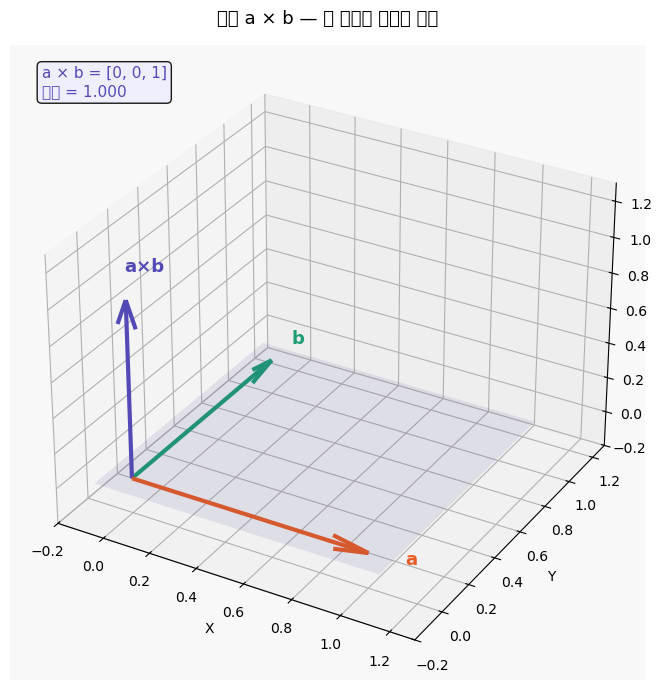

a × b = [0. 0. 1.]
수직 확인 — a·(a×b) = 0.000000 (0이어야 함)
수직 확인 — b·(a×b) = 0.000000 (0이어야 함)


In [6]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

a = np.array([1.0, 0.0, 0.0])
b = np.array([0.0, 1.0, 0.0])
c = np.cross(a, b)  # 외적

colors = {'a': '#E85D24', 'b': '#1D9E75', 'axb': '#534AB7'}
vecs = {'a': a, 'b': b, 'a×b': c}

for label, vec in vecs.items():
    color = colors.get(label, colors['axb'])
    ax.quiver(0, 0, 0, *vec, color=color, lw=3, arrow_length_ratio=0.15)
    ax.text(*(vec * 1.15), label, color=color, fontsize=13, fontweight='bold')

# 평면 표시
xx, yy = np.meshgrid(np.linspace(-0.1, 1.1, 3), np.linspace(-0.1, 1.1, 3))
zz = np.zeros_like(xx)
ax.plot_surface(xx, yy, zz, alpha=0.1, color='#534AB7')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('외적 a × b — 두 벡터에 수직인 방향', fontsize=13, pad=15)
ax.set_xlim(-0.2, 1.3); ax.set_ylim(-0.2, 1.3); ax.set_zlim(-0.2, 1.3)

result_text = f'a × b = [{c[0]:.0f}, {c[1]:.0f}, {c[2]:.0f}]\n크기 = {np.linalg.norm(c):.3f}'
ax.text2D(0.05, 0.92, result_text, transform=ax.transAxes,
          fontsize=11, color='#534AB7',
          bbox=dict(boxstyle='round', facecolor='#EEEDFE', alpha=0.9))

plt.tight_layout()
plt.savefig('assets/01_cross_product.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'a × b = {c}')
print(f'수직 확인 — a·(a×b) = {np.dot(a, c):.6f} (0이어야 함)')
print(f'수직 확인 — b·(a×b) = {np.dot(b, c):.6f} (0이어야 함)')

## 3. 행렬 곱셈 — 선형 변환의 합성

로보틱스에서 행렬 곱 = 좌표계 변환의 합성

$$T_{base \to end} = T_{base \to joint1} \cdot T_{joint1 \to joint2} \cdots$$

/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/2041505659.py:41: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/2041505659.py:41: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/2041505659.py:41: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/2041505659.py:41: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel_5807/2041505659.py:41: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nw/9j9wvll54ws3q3v2bp19yfjh0000gn/T/ipykernel

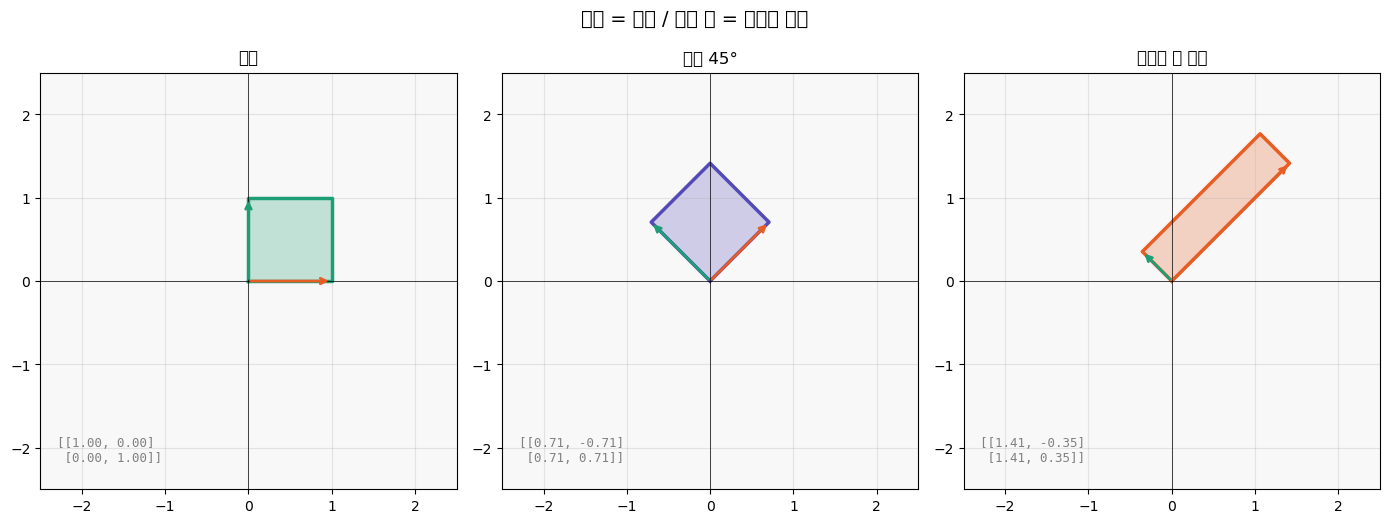

In [7]:
def rotation_matrix(theta_deg):
    theta = np.radians(theta_deg)
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta),  np.cos(theta)]])

def scale_matrix(sx, sy):
    return np.array([[sx, 0], [0, sy]])

# 단위 정사각형 꼭짓점
square = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T

R = rotation_matrix(45)
S = scale_matrix(2, 0.5)
RS = R @ S  # 합성 변환

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
transforms = [(np.eye(2), '원본'), (R, '회전 45°'), (RS, '스케일 후 회전')]
colors_list = ['#1D9E75', '#534AB7', '#E85D24']

for ax, (M, title), color in zip(axes, transforms, colors_list):
    transformed = M @ square
    ax.fill(transformed[0], transformed[1], alpha=0.25, color=color)
    ax.plot(transformed[0], transformed[1], color=color, lw=2.5)

    # 기저 벡터
    e1, e2 = M @ np.array([1,0]), M @ np.array([0,1])
    ax.annotate('', xy=e1, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color='#E85D24', lw=2))
    ax.annotate('', xy=e2, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=2))

    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(title, fontsize=12, pad=8)
    mat_str = f'[[{M[0,0]:.2f}, {M[0,1]:.2f}]\n [{M[1,0]:.2f}, {M[1,1]:.2f}]]'
    ax.text(-2.3, -2.2, mat_str, fontsize=9, fontfamily='monospace',
            color='gray', va='bottom')

plt.suptitle('행렬 = 변환 / 행렬 곱 = 변환의 합성', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('assets/01_matrix_multiplication.png', dpi=150, bbox_inches='tight')
plt.show()

## 요약 — 로보틱스 연결 정리

| 연산 | 수식 | 로보틱스 활용 |
|------|------|---------------|
| 벡터 덧셈 | $\vec{a} + \vec{b}$ | 힘 합성, 속도 합성 |
| 내적 | $\vec{a} \cdot \vec{b}$ | 관절 정렬도, 작업공간 분석 |
| 외적 | $\vec{a} \times \vec{b}$ | 회전축 계산, 토크 방향 |
| 행렬 곱 | $AB$ | 좌표계 변환 합성 |
